In [123]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import ParameterGrid
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import os


### hypertune iteration 1

In [124]:
### strategic hypertune iteration 1
param_grid = {
    'cnn_filters': [16, 32],
    'fc_size': [64, 1048],
    'sequence_length': [15, 45],
    'dropout_p': [0.1, 0.5],
    'batch_size': [32, 512],
    'lr': [0.0001, 0.01],
    'optimizer_type': ['adam', 'sgd'],
    'weight_decay':[0.0001, 0.01],
    'loss': ['bce'],
    'bce_pos_class_weight': [30, 75],
#     'scheduler_t': [5],
    'num_epochs': [50],
    'cv_folds': [5], 
}

grid = pd.read_csv("cnn_overlap_hypertune_grid_output_1.csv")
grid

,Unnamed: 0,batch_size,bce_pos_class_weight,cnn_filters,dropout_p,fc_size,lr,optimizer_type,sequence_length,weight_decay,tss,hss
0,589,2048,60,4,0.1,64,0.01,adam,60,0.010,0.3446,0.1082
1,420,2048,30,4,0.1,1048,0.01,adam,60,0.001,0.3437,0.1316
2,588,2048,60,4,0.1,64,0.01,adam,60,0.001,0.3416,0.1008
3,479,2048,30,4,0.3,1048,0.01,sgd,180,0.010,0.3406,0.1282
4,407,2048,30,4,0.1,64,0.01,sgd,180,0.010,0.3403,0.1253
...,...,...,...,...,...,...,...,...,...,...,...,...
763,376,1024,60,32,0.3,1048,0.01,adam,180,0.001,-0.0065,-0.0064
764,40,1024,30,4,0.1,1048,0.01,adam,180,0.001,-0.0387,-0.0112
765,310,1024,60,32,0.1,64,0.01,sgd,180,0.001,-0.0519,-0.0058
766,278,1024,60,4,0.3,1048,0.01,adam,120,0.001,-0.0619,-0.0031


In [125]:
grid.sort_values(by=['hss', 'tss'], ascending=False)

,Unnamed: 0,batch_size,bce_pos_class_weight,cnn_filters,dropout_p,fc_size,lr,optimizer_type,sequence_length,weight_decay,tss,hss
234,526,2048,30,32,0.1,1048,0.010,sgd,180,0.001,0.2685,0.1873
196,572,2048,30,32,0.3,1048,0.010,sgd,120,0.001,0.2749,0.1721
565,502,2048,30,32,0.1,64,0.010,sgd,180,0.001,0.2021,0.1716
119,508,2048,30,32,0.1,1048,0.001,adam,180,0.001,0.2908,0.1714
444,120,1024,30,32,0.1,1048,0.001,adam,60,0.001,0.2317,0.1688
...,...,...,...,...,...,...,...,...,...,...,...,...
766,278,1024,60,4,0.3,1048,0.010,adam,120,0.001,-0.0619,-0.0031
765,310,1024,60,32,0.1,64,0.010,sgd,180,0.001,-0.0519,-0.0058
763,376,1024,60,32,0.3,1048,0.010,adam,180,0.001,-0.0065,-0.0064
764,40,1024,30,4,0.1,1048,0.010,adam,180,0.001,-0.0387,-0.0112


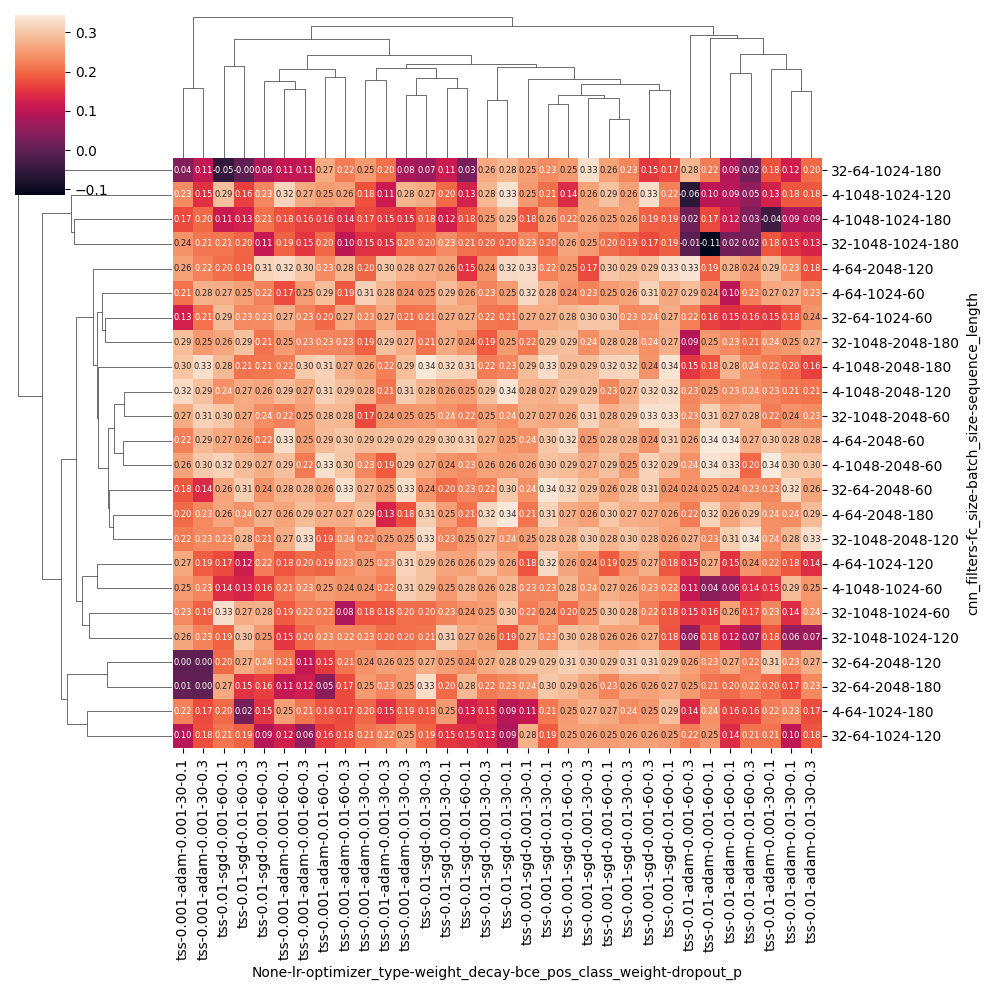

In [126]:
sns.clustermap(grid.pivot_table(
    values=['tss'], 
    index=['cnn_filters', 'fc_size', 'batch_size', 'sequence_length'],
    columns=['lr', 'optimizer_type', 'weight_decay', 'bce_pos_class_weight', 'dropout_p']        
), annot=True, fmt=".2f", annot_kws={'size': 6})

In [127]:
grid['optimizer_type'] = grid['optimizer_type'].astype('category')

formula = 'tss ~ ' + ' + '.join(grid.drop(['hss'], axis=1) .columns[:-1])
model = ols(formula, data=grid.drop(['hss'], axis=1) ).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
# anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

                        sum_sq     df           F        PR(>F)
optimizer_type        0.220055    1.0   69.384002  3.782539e-16
batch_size            0.593224    1.0  187.044985  3.232719e-38
bce_pos_class_weight  0.019119    1.0    6.028292  1.430190e-02
cnn_filters           0.062527    1.0   19.714911  1.032634e-05
dropout_p             0.000165    1.0    0.052119  8.194775e-01
fc_size               0.000096    1.0    0.030307  8.618416e-01
lr                    0.123472    1.0   38.931091  7.297757e-10
sequence_length       0.242299    1.0   76.397552  1.478655e-17
weight_decay          0.004907    1.0    1.547217  2.139313e-01
Residual              2.404042  758.0         NaN           NaN


/var/folders/v0/gfw_n5c13750s83v11_7kj2h0000gn/T/ipykernel_36336/2737790543.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.clustermap(grid.pivot_table(


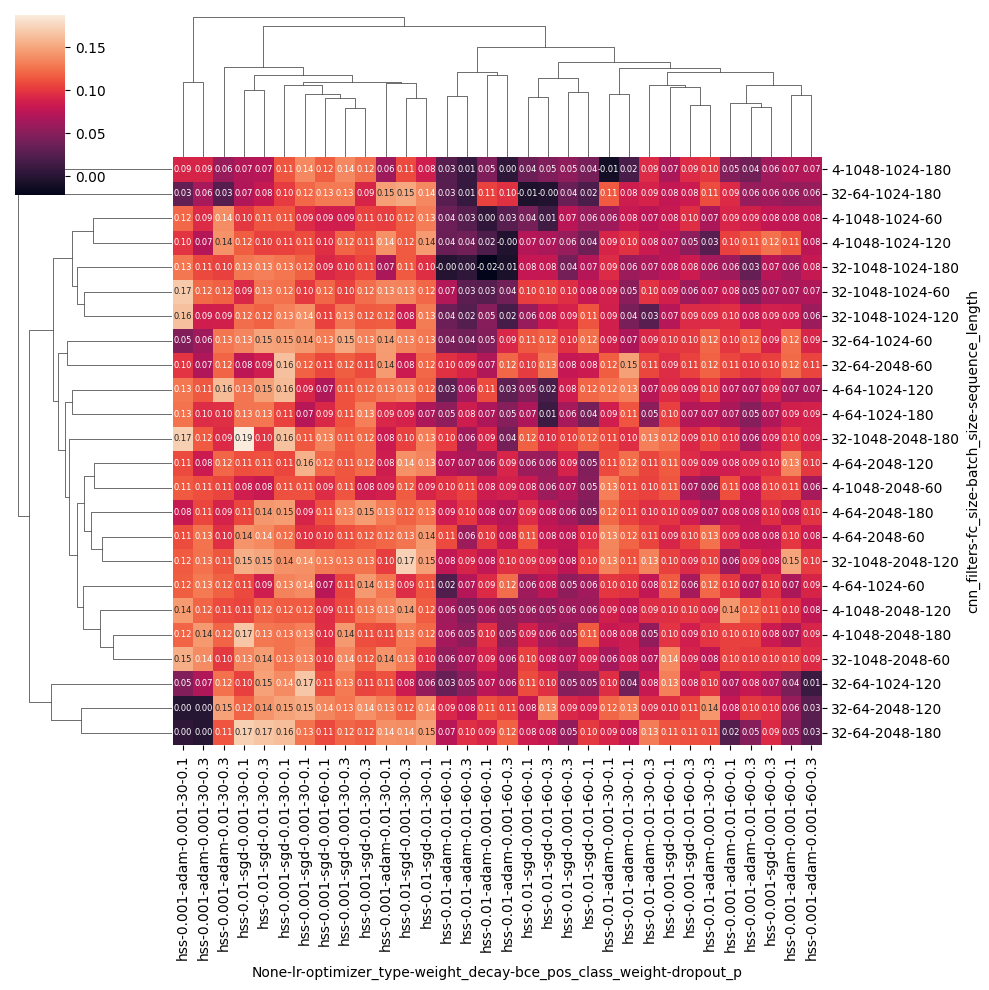

In [128]:
sns.clustermap(grid.pivot_table(
    values=['hss'], 
    index=['cnn_filters', 'fc_size', 'batch_size', 'sequence_length'],
    columns=['lr', 'optimizer_type', 'weight_decay', 'bce_pos_class_weight', 'dropout_p']        
), annot=True, fmt=".2f", annot_kws={'size': 6})

In [129]:
grid['optimizer_type'] = grid['optimizer_type'].astype('category')

formula = 'hss ~ ' + ' + '.join(grid.drop(['tss'], axis=1) .columns[:-1])
model = ols(formula, data=grid.drop(['tss'], axis=1) ).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
# anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

                        sum_sq     df           F        PR(>F)
optimizer_type        0.058405    1.0   85.770633  2.037383e-19
batch_size            0.049460    1.0   72.633783  8.389187e-17
bce_pos_class_weight  0.196454    1.0  288.502239  4.501701e-55
cnn_filters           0.003686    1.0    5.412335  2.025770e-02
dropout_p             0.007291    1.0   10.707854  1.115132e-03
fc_size               0.003396    1.0    4.987365  2.582417e-02
lr                    0.040868    1.0   60.017012  3.019742e-14
sequence_length       0.011638    1.0   17.090429  3.962043e-05
weight_decay          0.000023    1.0    0.033419  8.549978e-01
Residual              0.516157  758.0         NaN           NaN


### hypertune iteration 2

In [130]:
### strategic hypertune iteration 2
param_grid = {
    'cnn_filters': [4, 16, 64],  ### changed, added 1 dimension
    'fc_size': [128, 2048],  ### changed
    'sequence_length': [60, 180],  ### changed, removed 1 dimension
    'dropout_p': [0.1, 0.3],
    'batch_size': [2048, 4096],  ### changed
    'lr': [0.0075, 0.025],  ### changed
    'optimizer_type': ['adam', 'sgd'],
    'weight_decay':[0.001, 0.01],
    'loss': ['bce'],
    'bce_pos_class_weight': [30, 60],  ### changed
#     'scheduler_t': [5],
    'num_epochs': [15],
    'cv_folds': [5], 
}

grid = pd.read_csv("cnn_overlap_hypertune_grid_output_2.csv")
grid

,Unnamed: 0,batch_size,bce_pos_class_weight,cnn_filters,dropout_p,fc_size,lr,optimizer_type,sequence_length,weight_decay,tss,hss
0,708,4096,60,64,0.1,128,0.0075,sgd,60,0.001,0.4104,0.1247
1,672,4096,60,16,0.3,128,0.0075,adam,60,0.001,0.3878,0.1086
2,684,4096,60,16,0.3,128,0.0250,sgd,60,0.001,0.3825,0.1342
3,457,4096,30,16,0.1,128,0.0250,adam,60,0.010,0.3812,0.1009
4,717,4096,60,64,0.1,128,0.0250,sgd,60,0.010,0.3790,0.1069
...,...,...,...,...,...,...,...,...,...,...,...,...
763,59,2048,30,4,0.3,2048,0.0250,adam,180,0.010,0.0113,0.0002
764,334,2048,60,64,0.1,128,0.0250,sgd,180,0.001,-0.0005,-0.0008
765,171,2048,30,64,0.3,128,0.0250,adam,180,0.010,-0.0201,-0.0062
766,187,2048,30,64,0.3,2048,0.0250,adam,180,0.010,-0.0487,-0.0124


In [131]:
grid.sort_values(by=['hss', 'tss'], ascending=False)

,Unnamed: 0,batch_size,bce_pos_class_weight,cnn_filters,dropout_p,fc_size,lr,optimizer_type,sequence_length,weight_decay,tss,hss
456,575,4096,30,64,0.3,2048,0.0250,sgd,180,0.010,0.2431,0.2131
410,574,4096,30,64,0.3,2048,0.0250,sgd,180,0.001,0.2508,0.1636
200,455,4096,30,16,0.1,128,0.0075,sgd,180,0.010,0.2890,0.1634
175,36,2048,30,4,0.3,128,0.0075,sgd,60,0.001,0.2929,0.1627
167,662,4096,60,16,0.1,2048,0.0075,sgd,180,0.001,0.2942,0.1623
...,...,...,...,...,...,...,...,...,...,...,...,...
763,59,2048,30,4,0.3,2048,0.0250,adam,180,0.010,0.0113,0.0002
767,27,2048,30,4,0.1,2048,0.0250,adam,180,0.010,-0.0697,0.0002
764,334,2048,60,64,0.1,128,0.0250,sgd,180,0.001,-0.0005,-0.0008
765,171,2048,30,64,0.3,128,0.0250,adam,180,0.010,-0.0201,-0.0062


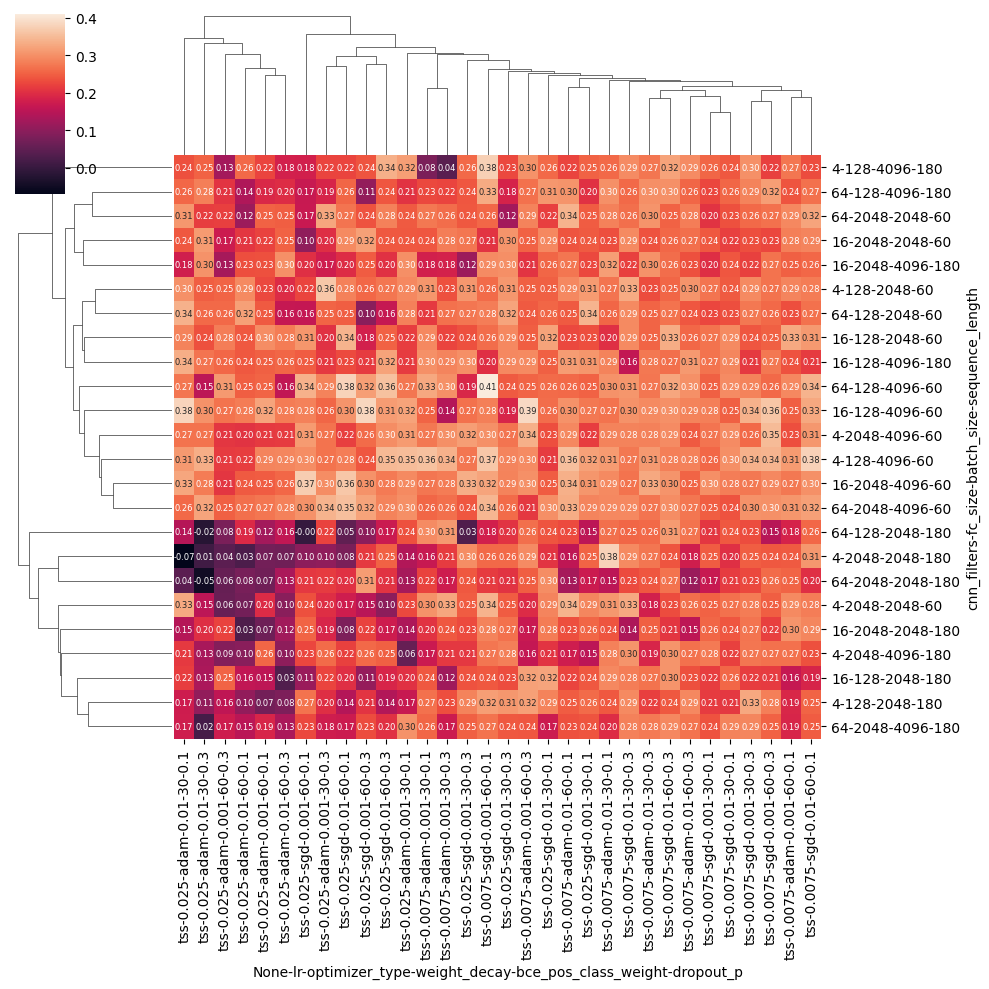

In [132]:
sns.clustermap(grid.pivot_table(
    values=['tss'], 
    index=['cnn_filters', 'fc_size', 'batch_size', 'sequence_length'],
    columns=['lr', 'optimizer_type', 'weight_decay', 'bce_pos_class_weight', 'dropout_p']        
), annot=True, fmt=".2f", annot_kws={'size': 6})

In [133]:
grid['optimizer_type'] = grid['optimizer_type'].astype('category')

formula = 'tss ~ ' + ' + '.join(grid.drop(['hss'], axis=1) .columns[:-1])
model = ols(formula, data=grid.drop(['hss'], axis=1) ).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
# anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

                        sum_sq     df           F        PR(>F)
optimizer_type        0.095859    1.0   30.841468  3.875696e-08
batch_size            0.235725    1.0   75.841625  1.909724e-17
bce_pos_class_weight  0.013877    1.0    4.464781  3.492682e-02
cnn_filters           0.010159    1.0    3.268467  7.101986e-02
dropout_p             0.001209    1.0    0.388986  5.330206e-01
fc_size               0.056160    1.0   18.068711  2.396524e-05
lr                    0.264746    1.0   85.178610  2.666367e-19
sequence_length       0.539264    1.0  173.501486  7.915957e-36
weight_decay          0.001427    1.0    0.459058  4.982712e-01
Residual              2.355959  758.0         NaN           NaN


/var/folders/v0/gfw_n5c13750s83v11_7kj2h0000gn/T/ipykernel_36336/2737790543.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.clustermap(grid.pivot_table(


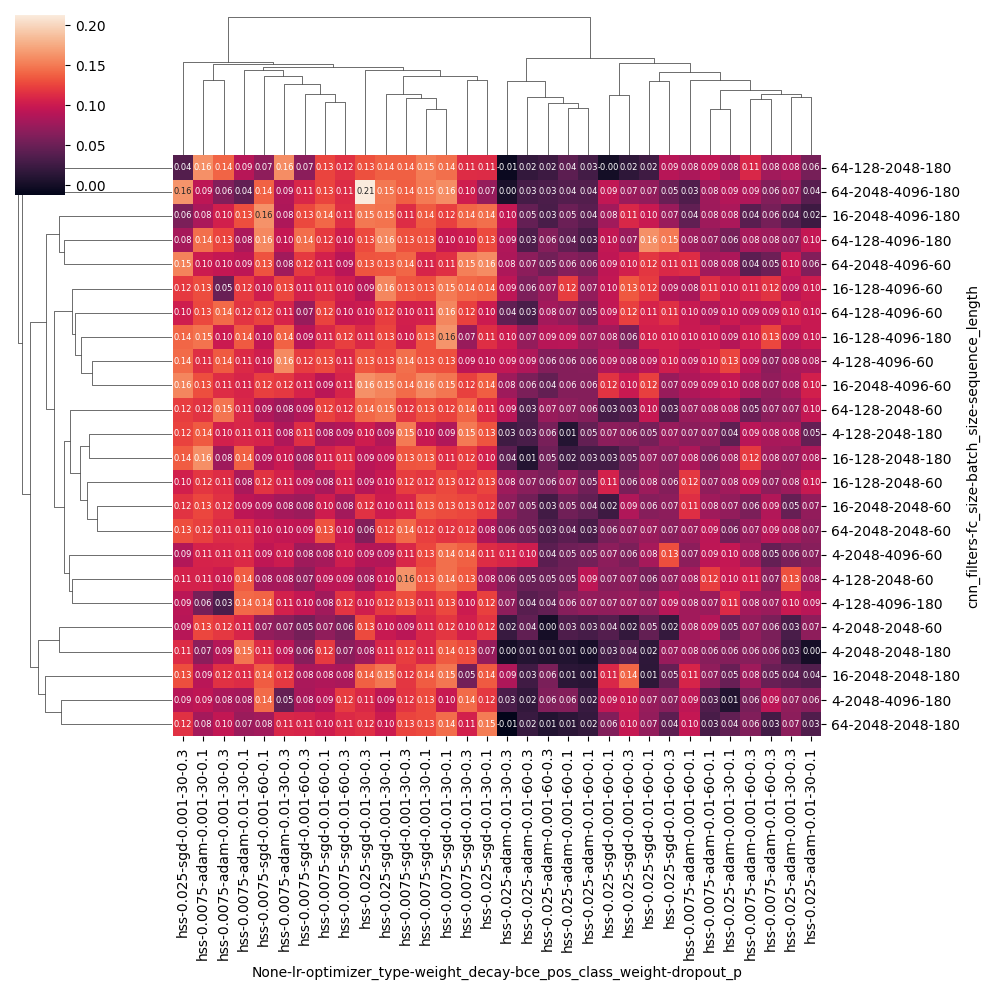

In [134]:
sns.clustermap(grid.pivot_table(
    values=['hss'], 
    index=['cnn_filters', 'fc_size', 'batch_size', 'sequence_length'],
    columns=['lr', 'optimizer_type', 'weight_decay', 'bce_pos_class_weight', 'dropout_p']        
), annot=True, fmt=".2f", annot_kws={'size': 6})

In [135]:
grid['optimizer_type'] = grid['optimizer_type'].astype('category')

formula = 'hss ~ ' + ' + '.join(grid.drop(['tss'], axis=1) .columns[:-1])
model = ols(formula, data=grid.drop(['tss'], axis=1) ).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
# anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

                        sum_sq     df           F        PR(>F)
optimizer_type        0.170343    1.0  281.931135  4.940407e-54
batch_size            0.036647    1.0   60.654296  2.237351e-14
bce_pos_class_weight  0.159229    1.0  263.537628  4.382915e-51
cnn_filters           0.001276    1.0    2.111685  1.465921e-01
dropout_p             0.005625    1.0    9.309285  2.359475e-03
fc_size               0.016349    1.0   27.058169  2.542997e-07
lr                    0.134806    1.0  223.114029  2.063394e-44
sequence_length       0.010631    1.0   17.595440  3.055665e-05
weight_decay          0.001392    1.0    2.303197  1.295249e-01
Residual              0.457984  758.0         NaN           NaN


### hypertune iteration 3

In [136]:
### strategic hypertune iteration 3
param_grid = {
    'cnn_filters': [64, 256],  ### changed, removed 1 dimension
    'fc_size': [512, 2048],  ### changed
    'sequence_length': [60, 120, 300],  ### changed, added 1 dimension
    'dropout_p': [0.1, 0.3],
    'batch_size': [1024, 4096],  ### changed
    'lr': [0.005, 0.05],  ### changed
    'optimizer_type': ['adam', 'sgd'],
    'weight_decay':[0.001, 0.01],
    'loss': ['bce'],
    'bce_pos_class_weight': [20, 60],  ### changed
#     'scheduler_t': [5],
    'num_epochs': [15],
    'cv_folds': [5], 
}

grid = pd.read_csv("cnn_overlap_hypertune_grid_output_3.csv")
grid

,Unnamed: 0,batch_size,bce_pos_class_weight,cnn_filters,dropout_p,fc_size,lr,optimizer_type,sequence_length,weight_decay,tss,hss
0,595,4096,60,64,0.1,512,0.050,sgd,60,0.010,0.3685,0.0879
1,445,4096,20,64,0.3,512,0.050,adam,60,0.010,0.3607,0.1092
2,594,4096,60,64,0.1,512,0.050,sgd,60,0.001,0.3596,0.1244
3,481,4096,20,256,0.1,512,0.005,adam,60,0.010,0.3538,0.1618
4,730,4096,60,256,0.3,512,0.005,sgd,300,0.001,0.3534,0.1349
...,...,...,...,...,...,...,...,...,...,...,...,...
763,325,1024,60,256,0.1,2048,0.050,adam,60,0.010,-0.1254,-0.0000
764,234,1024,60,64,0.1,2048,0.050,sgd,60,0.001,-0.1440,-0.0274
765,349,1024,60,256,0.3,512,0.050,adam,60,0.010,-0.1499,-0.0274
766,262,1024,60,64,0.3,512,0.050,sgd,300,0.001,-0.1517,-0.0324


In [137]:
grid.sort_values(by=['hss', 'tss'], ascending=False)

,Unnamed: 0,batch_size,bce_pos_class_weight,cnn_filters,dropout_p,fc_size,lr,optimizer_type,sequence_length,weight_decay,tss,hss
71,525,4096,20,256,0.1,2048,0.050,sgd,120,0.010,0.2876,0.2079
115,511,4096,20,256,0.1,2048,0.005,sgd,60,0.010,0.2756,0.1970
38,572,4096,20,256,0.3,2048,0.050,sgd,120,0.001,0.3117,0.1910
273,392,4096,20,64,0.1,512,0.005,sgd,120,0.001,0.2138,0.1900
135,416,4096,20,64,0.1,2048,0.005,sgd,120,0.001,0.2647,0.1891
...,...,...,...,...,...,...,...,...,...,...,...,...
762,372,1024,60,256,0.3,2048,0.050,adam,60,0.001,-0.1188,-0.0224
764,234,1024,60,64,0.1,2048,0.050,sgd,60,0.001,-0.1440,-0.0274
765,349,1024,60,256,0.3,512,0.050,adam,60,0.010,-0.1499,-0.0274
767,307,1024,60,256,0.1,512,0.050,sgd,60,0.010,-0.1683,-0.0311


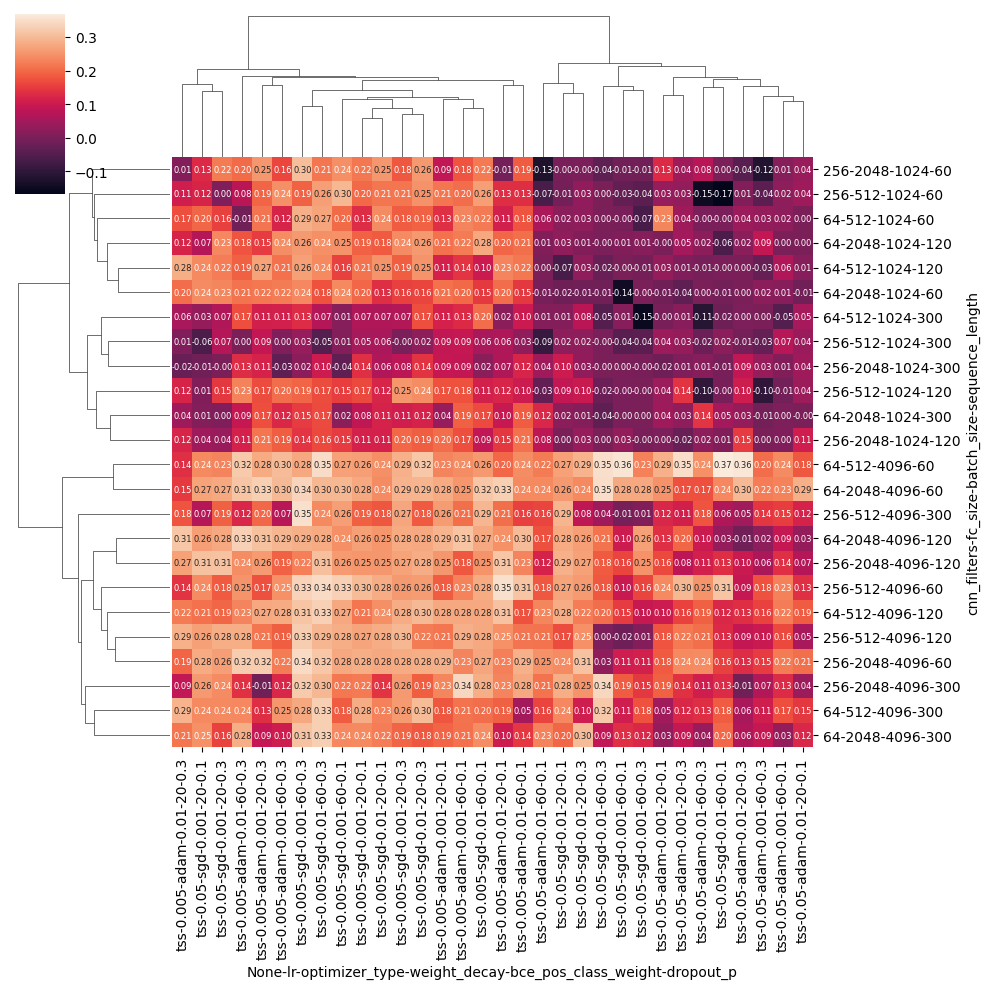

In [138]:
sns.clustermap(grid.pivot_table(
    values=['tss'], 
    index=['cnn_filters', 'fc_size', 'batch_size', 'sequence_length'],
    columns=['lr', 'optimizer_type', 'weight_decay', 'bce_pos_class_weight', 'dropout_p']        
), annot=True, fmt=".2f", annot_kws={'size': 6})

In [139]:
grid['optimizer_type'] = grid['optimizer_type'].astype('category')

formula = 'tss ~ ' + ' + '.join(grid.drop(['hss'], axis=1) .columns[:-1])
model = ols(formula, data=grid.drop(['hss'], axis=1) ).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
# anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

                        sum_sq     df           F         PR(>F)
optimizer_type        0.153417    1.0   32.595558   1.628852e-08
batch_size            3.224487    1.0  685.085229  4.426638e-108
bce_pos_class_weight  0.040532    1.0    8.611567   3.441251e-03
cnn_filters           0.070765    1.0   15.035061   1.146873e-04
dropout_p             0.001000    1.0    0.212436   6.449969e-01
fc_size               0.004088    1.0    0.868563   3.516503e-01
lr                    2.006483    1.0  426.303962   1.717540e-75
sequence_length       0.606346    1.0  128.826379   1.099962e-27
weight_decay          0.009266    1.0    1.968778   1.609871e-01
Residual              3.567674  758.0         NaN            NaN


/var/folders/v0/gfw_n5c13750s83v11_7kj2h0000gn/T/ipykernel_36336/2737790543.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.clustermap(grid.pivot_table(


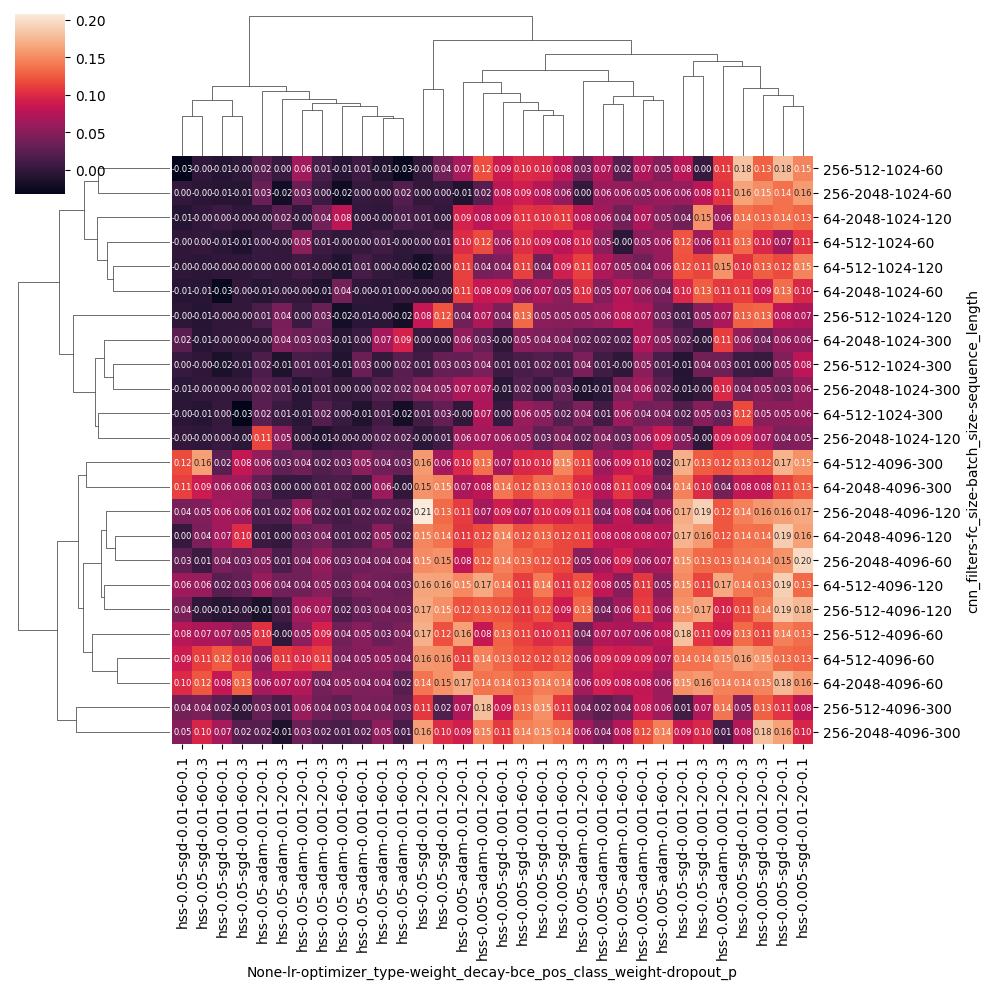

In [140]:
sns.clustermap(grid.pivot_table(
    values=['hss'], 
    index=['cnn_filters', 'fc_size', 'batch_size', 'sequence_length'],
    columns=['lr', 'optimizer_type', 'weight_decay', 'bce_pos_class_weight', 'dropout_p']        
), annot=True, fmt=".2f", annot_kws={'size': 6})

In [141]:
grid['optimizer_type'] = grid['optimizer_type'].astype('category')

formula = 'hss ~ ' + ' + '.join(grid.drop(['tss'], axis=1) .columns[:-1])
model = ols(formula, data=grid.drop(['tss'], axis=1) ).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
# anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

                        sum_sq     df           F        PR(>F)
optimizer_type        0.193653    1.0  171.987911  1.471295e-35
batch_size            0.463647    1.0  411.776302  1.867661e-73
bce_pos_class_weight  0.180384    1.0  160.203961  1.901598e-33
cnn_filters           0.019903    1.0   17.676644  2.930801e-05
dropout_p             0.004169    1.0    3.702365  5.470949e-02
fc_size               0.000029    1.0    0.025915  8.721502e-01
lr                    0.439545    1.0  390.371248  2.082549e-70
sequence_length       0.067597    1.0   60.034563  2.994894e-14
weight_decay          0.004543    1.0    4.034783  4.492560e-02
Residual              0.853483  758.0         NaN           NaN


### hypertune iteration 4

In [142]:
### strategic hypertune iteration 4
param_grid = {
    'cnn_filters': [8, 32],  ### changed
    'fc_size': [128, 512],  ### changed
    'sequence_length': [30, 60, 120],  ### changed
    'dropout_p': [0.1, 0.3],
    'batch_size': [2048, 4096],  ### changed
    'lr': [0.0075, 0.03],  ### changed
    'optimizer_type': ['adam', 'sgd'],
    'weight_decay':[0.001, 0.05],  ### changed
    'loss': ['bce'],
    'bce_pos_class_weight': [15, 50],  ### changed
#     'scheduler_t': [5],
    'num_epochs': [15],
    'cv_folds': [5], 
}

grid = pd.read_csv("cnn_overlap_hypertune_grid_output_4.csv")
grid

,Unnamed: 0,batch_size,bce_pos_class_weight,cnn_filters,dropout_p,fc_size,lr,optimizer_type,sequence_length,weight_decay,tss,hss
0,630,4096,50,8,0.3,128,0.0075,sgd,30,0.001,0.4439,0.1438
1,673,4096,50,32,0.1,128,0.0075,adam,30,0.050,0.4119,0.1194
2,714,4096,50,32,0.1,512,0.0300,sgd,30,0.001,0.3973,0.1374
3,582,4096,50,8,0.1,128,0.0075,sgd,30,0.001,0.3930,0.1395
4,762,4096,50,32,0.3,512,0.0300,sgd,30,0.001,0.3914,0.1260
...,...,...,...,...,...,...,...,...,...,...,...,...
763,185,2048,15,32,0.3,512,0.0300,adam,120,0.050,0.0117,0.0118
764,159,2048,15,32,0.3,128,0.0300,adam,60,0.050,0.0091,0.0036
765,213,2048,50,8,0.1,128,0.0300,sgd,60,0.050,-0.0002,-0.0003
766,261,2048,50,8,0.3,128,0.0300,sgd,60,0.050,-0.0011,-0.0018


In [143]:
grid.sort_values(by=['hss', 'tss'], ascending=False)

,Unnamed: 0,batch_size,bce_pos_class_weight,cnn_filters,dropout_p,fc_size,lr,optimizer_type,sequence_length,weight_decay,tss,hss
313,431,4096,15,8,0.1,512,0.0300,sgd,120,0.050,0.2691,0.2144
141,503,4096,15,32,0.1,128,0.0300,sgd,120,0.050,0.3044,0.2070
153,4,2048,15,8,0.1,128,0.0075,adam,120,0.001,0.3032,0.2057
162,59,2048,15,8,0.3,128,0.0075,sgd,120,0.050,0.3008,0.2043
10,384,4096,15,8,0.1,128,0.0075,adam,30,0.001,0.3805,0.2024
...,...,...,...,...,...,...,...,...,...,...,...,...
762,87,2048,15,8,0.3,512,0.0300,adam,60,0.050,0.0130,0.0029
726,333,2048,50,32,0.1,512,0.0300,sgd,60,0.050,0.1016,0.0023
749,283,2048,50,8,0.3,512,0.0300,sgd,30,0.050,0.0509,0.0001
765,213,2048,50,8,0.1,128,0.0300,sgd,60,0.050,-0.0002,-0.0003


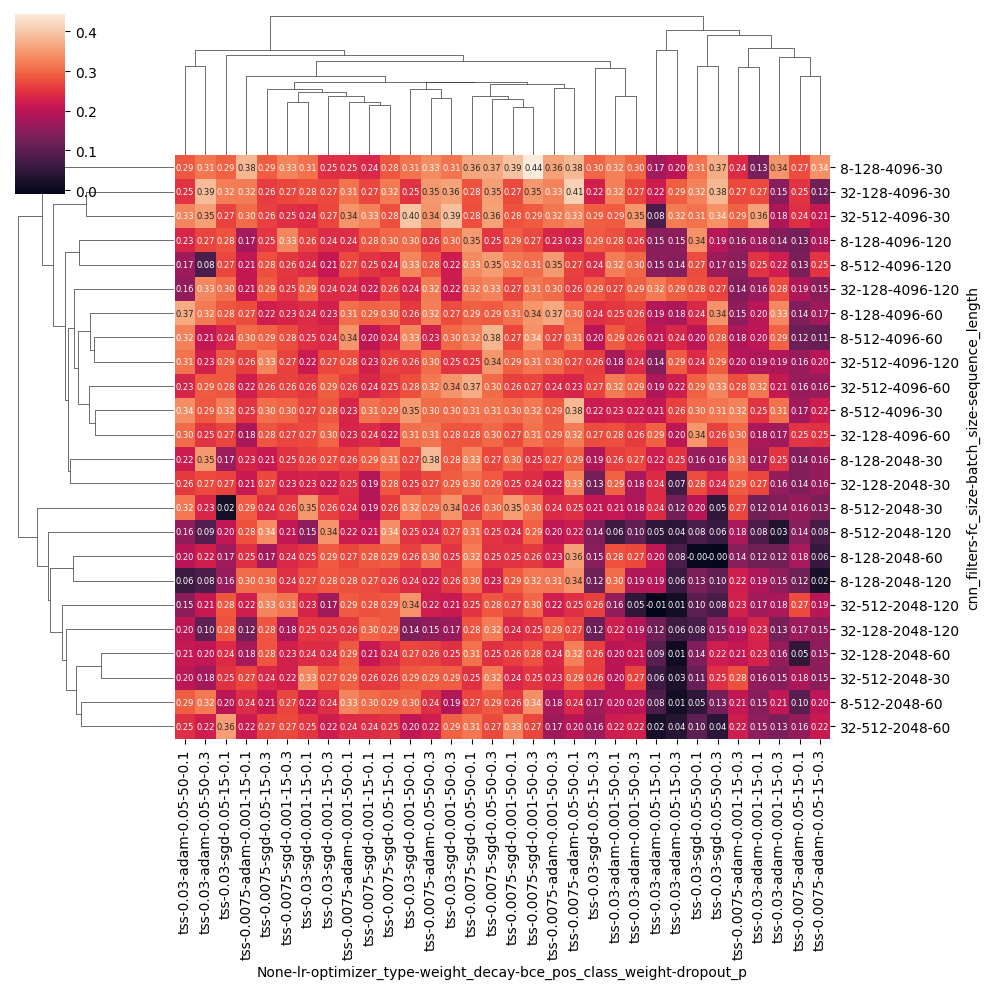

In [144]:
sns.clustermap(grid.pivot_table(
    values=['tss'], 
    index=['cnn_filters', 'fc_size', 'batch_size', 'sequence_length'],
    columns=['lr', 'optimizer_type', 'weight_decay', 'bce_pos_class_weight', 'dropout_p']        
), annot=True, fmt=".2f", annot_kws={'size': 6})

In [145]:
grid['optimizer_type'] = grid['optimizer_type'].astype('category')

formula = 'tss ~ ' + ' + '.join(grid.drop(['hss'], axis=1) .columns[:-1])
model = ols(formula, data=grid.drop(['hss'], axis=1) ).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
# anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

                        sum_sq     df           F        PR(>F)
optimizer_type        0.279788    1.0   80.223271  2.555924e-18
batch_size            0.519527    1.0  148.963093  2.086998e-31
bce_pos_class_weight  0.362082    1.0  103.819181  6.156880e-23
cnn_filters           0.001384    1.0    0.396773  5.289502e-01
dropout_p             0.004486    1.0    1.286211  2.571059e-01
fc_size               0.008521    1.0    2.443118  1.184587e-01
lr                    0.227863    1.0   65.334683  2.494327e-15
sequence_length       0.171526    1.0   49.181363  5.172716e-12
weight_decay          0.075511    1.0   21.651276  3.858725e-06
Residual              2.643617  758.0         NaN           NaN


/var/folders/v0/gfw_n5c13750s83v11_7kj2h0000gn/T/ipykernel_36336/2737790543.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.clustermap(grid.pivot_table(


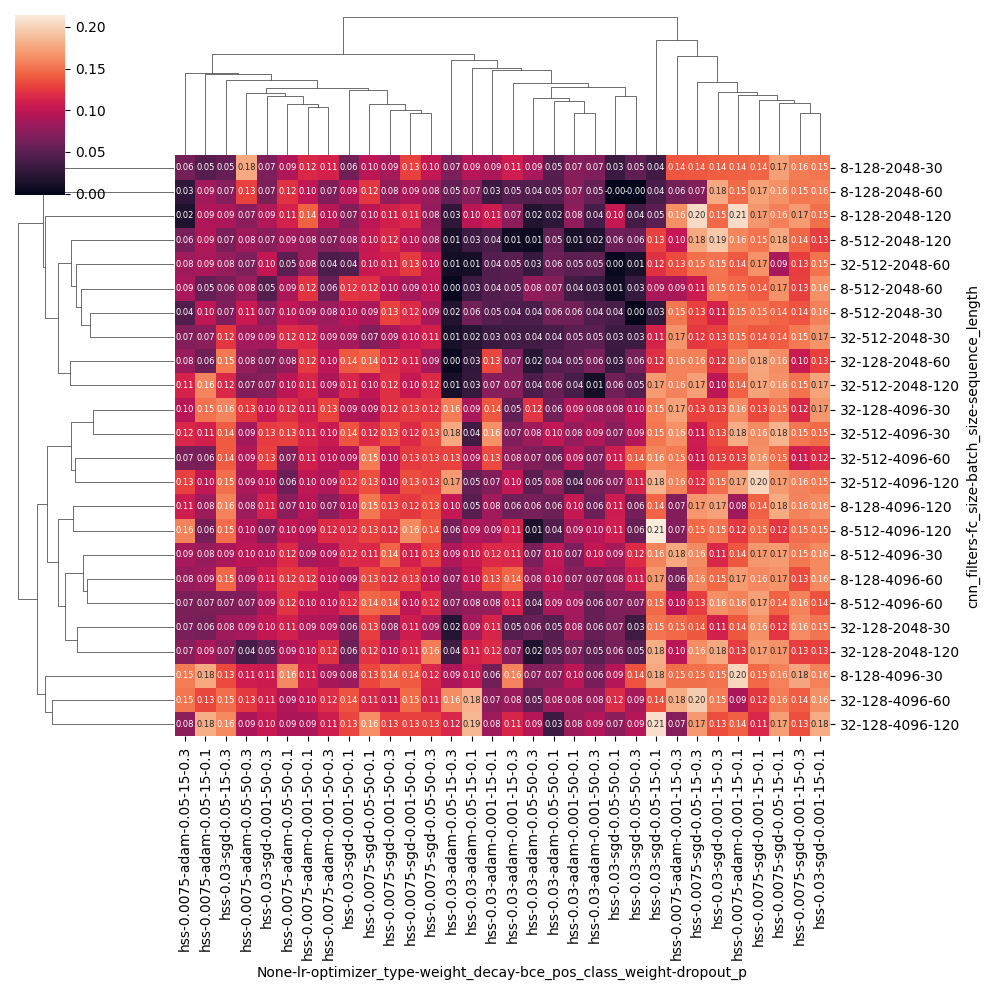

In [146]:
sns.clustermap(grid.pivot_table(
    values=['hss'], 
    index=['cnn_filters', 'fc_size', 'batch_size', 'sequence_length'],
    columns=['lr', 'optimizer_type', 'weight_decay', 'bce_pos_class_weight', 'dropout_p']        
), annot=True, fmt=".2f", annot_kws={'size': 6})

In [147]:
grid['optimizer_type'] = grid['optimizer_type'].astype('category')

formula = 'hss ~ ' + ' + '.join(grid.drop(['tss'], axis=1) .columns[:-1])
model = ols(formula, data=grid.drop(['tss'], axis=1) ).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
# anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

                        sum_sq     df           F        PR(>F)
optimizer_type        0.202716    1.0  224.390196  1.257993e-44
batch_size            0.116876    1.0  129.372145  8.696458e-28
bce_pos_class_weight  0.183089    1.0  202.664917  6.275010e-41
cnn_filters           0.003926    1.0    4.345655  3.743768e-02
dropout_p             0.018573    1.0   20.559079  6.718131e-06
fc_size               0.008576    1.0    9.493020  2.137144e-03
lr                    0.184735    1.0  204.487477  3.048766e-41
sequence_length       0.000016    1.0    0.017696  8.942065e-01
weight_decay          0.043218    1.0   47.838944  9.842626e-12
Residual              0.684782  758.0         NaN           NaN


### hypertune iteration 5

In [148]:
### strategic hypertune iteration 5
param_grid = {
    'cnn_filters': [16, 48],  ### changed
    'fc_size': [256, 768],  ### changed
    'sequence_length': [30, 60, 120],  
    'dropout_p': [0.05, 0.4],  ### changed
    'batch_size': [3584, 4864],  ### changed
    'lr': [0.005, 0.025],  ### changed
    'optimizer_type': ['adam', 'sgd'],
    'weight_decay':[0.0025, 0.05],  ### changed
    'loss': ['bce'],
    'bce_pos_class_weight': [15, 50],  
#     'scheduler_t': [5],
    'num_epochs': [15],
    'cv_folds': [5], 
}

grid = pd.read_csv("cnn_overlap_hypertune_grid_output_5.csv")
grid

,Unnamed: 0,batch_size,bce_pos_class_weight,cnn_filters,dropout_p,fc_size,lr,optimizer_type,sequence_length,weight_decay,tss,hss
0,336,3584,50,48,0.40,256,0.005,adam,30,0.0025,0.4354,0.1377
1,753,4864,50,48,0.40,768,0.005,sgd,60,0.0500,0.4242,0.1585
2,675,4864,50,48,0.05,256,0.005,adam,60,0.0500,0.4167,0.1705
3,340,3584,50,48,0.40,256,0.005,adam,120,0.0025,0.4142,0.1262
4,650,4864,50,16,0.40,768,0.005,adam,60,0.0025,0.4124,0.1190
...,...,...,...,...,...,...,...,...,...,...,...,...
763,61,3584,15,16,0.40,256,0.025,adam,30,0.0500,0.0933,0.0746
764,39,3584,15,16,0.05,768,0.025,adam,60,0.0500,0.0868,0.0362
765,569,4864,15,48,0.40,768,0.025,adam,120,0.0500,0.0741,0.0157
766,521,4864,15,48,0.05,768,0.025,adam,120,0.0500,0.0496,0.0166


In [149]:
grid.sort_values(by=['hss', 'tss'], ascending=False)

,Unnamed: 0,batch_size,bce_pos_class_weight,cnn_filters,dropout_p,fc_size,lr,optimizer_type,sequence_length,weight_decay,tss,hss
256,97,3584,15,48,0.05,256,0.005,adam,30,0.0500,0.3197,0.2223
37,34,3584,15,16,0.05,768,0.005,sgd,120,0.0025,0.3695,0.2187
240,402,4864,15,16,0.05,256,0.025,sgd,30,0.0025,0.3221,0.2176
576,526,4864,15,48,0.05,768,0.025,sgd,120,0.0025,0.2634,0.2172
105,44,3584,15,16,0.05,768,0.025,sgd,60,0.0025,0.3461,0.2139
...,...,...,...,...,...,...,...,...,...,...,...,...
693,352,3584,50,48,0.40,256,0.025,adam,120,0.0025,0.2029,0.0328
728,377,3584,50,48,0.40,768,0.025,adam,120,0.0500,0.1783,0.0289
766,521,4864,15,48,0.05,768,0.025,adam,120,0.0500,0.0496,0.0166
765,569,4864,15,48,0.40,768,0.025,adam,120,0.0500,0.0741,0.0157


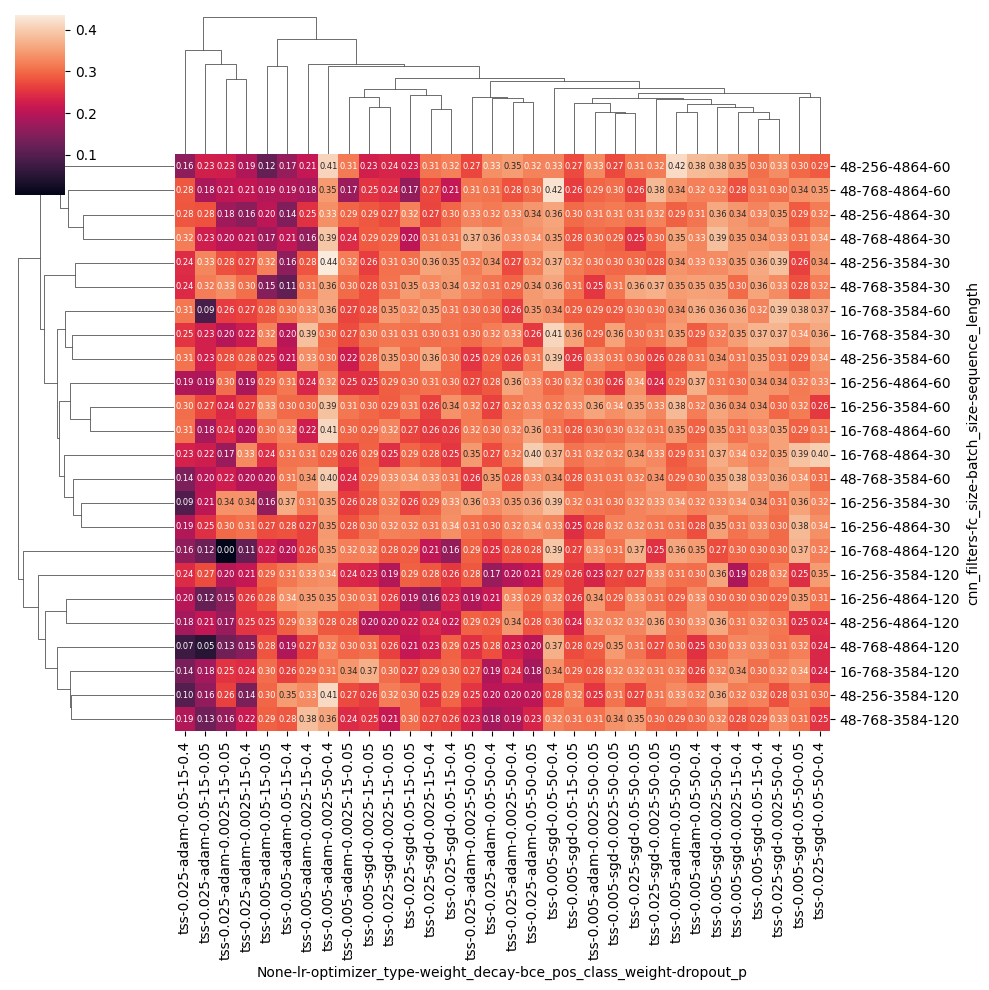

In [150]:
sns.clustermap(grid.pivot_table(
    values=['tss'], 
    index=['cnn_filters', 'fc_size', 'batch_size', 'sequence_length'],
    columns=['lr', 'optimizer_type', 'weight_decay', 'bce_pos_class_weight', 'dropout_p']        
), annot=True, fmt=".2f", annot_kws={'size': 6})

In [151]:
grid['optimizer_type'] = grid['optimizer_type'].astype('category')

formula = 'tss ~ ' + ' + '.join(grid.drop(['hss'], axis=1) .columns[:-1])
model = ols(formula, data=grid.drop(['hss'], axis=1) ).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
# anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

                        sum_sq     df           F        PR(>F)
optimizer_type        0.208336    1.0   96.567913  1.562133e-21
batch_size            0.024623    1.0   11.413153  7.665103e-04
bce_pos_class_weight  0.423508    1.0  196.304109  7.879448e-40
cnn_filters           0.010548    1.0    4.889197  2.732299e-02
dropout_p             0.037876    1.0   17.556259  3.117814e-05
fc_size               0.000413    1.0    0.191576  6.617331e-01
lr                    0.160089    1.0   74.204259  4.061563e-17
sequence_length       0.151072    1.0   70.024705  2.809302e-16
weight_decay          0.006053    1.0    2.805461  9.435630e-02
Residual              1.635314  758.0         NaN           NaN


/var/folders/v0/gfw_n5c13750s83v11_7kj2h0000gn/T/ipykernel_36336/2737790543.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.clustermap(grid.pivot_table(


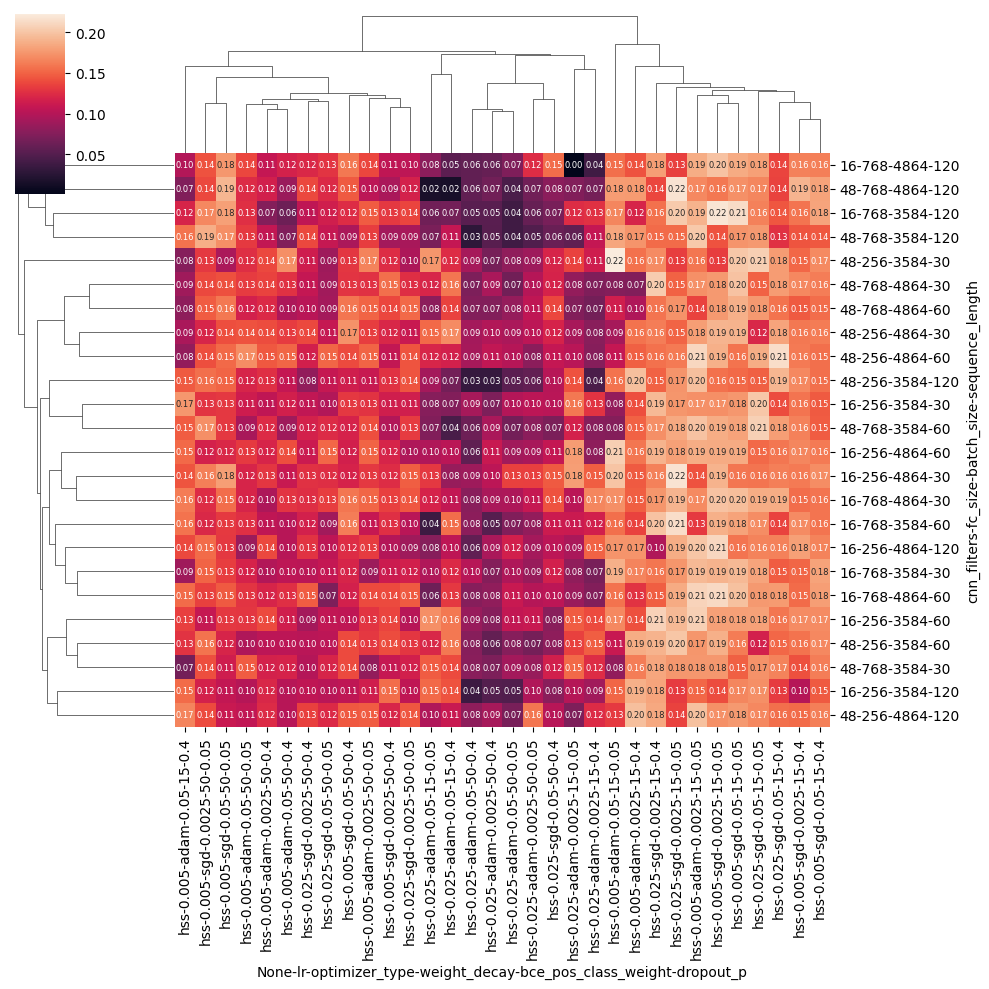

In [152]:
sns.clustermap(grid.pivot_table(
    values=['hss'], 
    index=['cnn_filters', 'fc_size', 'batch_size', 'sequence_length'],
    columns=['lr', 'optimizer_type', 'weight_decay', 'bce_pos_class_weight', 'dropout_p']        
), annot=True, fmt=".2f", annot_kws={'size': 6})

In [153]:
grid['optimizer_type'] = grid['optimizer_type'].astype('category')

formula = 'hss ~ ' + ' + '.join(grid.drop(['tss'], axis=1) .columns[:-1])
model = ols(formula, data=grid.drop(['tss'], axis=1) ).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
# anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

                        sum_sq     df           F        PR(>F)
optimizer_type        0.199905    1.0  262.484803  6.488260e-51
batch_size            0.004696    1.0    6.165516  1.324169e-02
bce_pos_class_weight  0.255267    1.0  335.177474  2.807054e-62
cnn_filters           0.002705    1.0    3.552127  5.985152e-02
dropout_p             0.027075    1.0   35.550783  3.808050e-09
fc_size               0.005239    1.0    6.878516  8.899018e-03
lr                    0.139590    1.0  183.288751  1.474299e-37
sequence_length       0.011224    1.0   14.737479  1.338749e-04
weight_decay          0.009412    1.0   12.358674  4.650255e-04
Residual              0.577283  758.0         NaN           NaN


#### combine iterations and evaluate

In [154]:
all_iterations = [
    "cnn_overlap_hypertune_grid_output_1.csv",
    "cnn_overlap_hypertune_grid_output_2.csv",
    "cnn_overlap_hypertune_grid_output_3.csv",
    "cnn_overlap_hypertune_grid_output_4.csv",
    "cnn_overlap_hypertune_grid_output_5.csv",
    ]

dfs = []
for file in all_iterations:
    # if file.endswith('.csv'):
    df = pd.read_csv(file)
    df['iteration'] = file[-6:-4]
    dfs.append(df)

combined_all_iterations = pd.concat(dfs, ignore_index=True)
combined_all_iterations = combined_all_iterations.sort_values(by='tss', ascending=False)
print(len(combined_all_iterations))
combined_all_iterations = \
    combined_all_iterations.drop_duplicates(subset=['batch_size', 
                                                    'bce_pos_class_weight',
                                                    'dropout_p',
                                                    'cnn_filters',
                                                    'lr',
                                                    'fc_size',
                                                    'optimizer_type',
                                                    'sequence_length',
                                                    'weight_decay',])
print(len(combined_all_iterations))
combined_all_iterations.head(20)
# combined_all_iterations.head(20).to_csv("cnn_overlap_TSS_top20_tunedModels.csv")


3840
3840


,Unnamed: 0,batch_size,bce_pos_class_weight,cnn_filters,dropout_p,fc_size,lr,optimizer_type,sequence_length,weight_decay,tss,hss,iteration
2304,630,4096,50,8,0.30,128,0.0075,sgd,30,0.0010,0.4439,0.1438,_4
3072,336,3584,50,48,0.40,256,0.0050,adam,30,0.0025,0.4354,0.1377,_5
3073,753,4864,50,48,0.40,768,0.0050,sgd,60,0.0500,0.4242,0.1585,_5
3074,675,4864,50,48,0.05,256,0.0050,adam,60,0.0500,0.4167,0.1705,_5
3075,340,3584,50,48,0.40,256,0.0050,adam,120,0.0025,0.4142,0.1262,_5
3076,650,4864,50,16,0.40,768,0.0050,adam,60,0.0025,0.4124,0.1190,_5
2305,673,4096,50,32,0.10,128,0.0075,adam,30,0.0500,0.4119,0.1194,_4
3077,271,3584,50,16,0.40,768,0.0050,sgd,30,0.0500,0.4109,0.1191,_5
768,708,4096,60,64,0.10,128,0.0075,sgd,60,0.0010,0.4104,0.1247,_2
3078,722,4864,50,48,0.40,256,0.0050,adam,60,0.0025,0.4099,0.1453,_5


In [155]:
combined_all_iterations = pd.concat(dfs, ignore_index=True)
combined_all_iterations = combined_all_iterations.sort_values(by='hss', ascending=False)
print(len(combined_all_iterations))
combined_all_iterations = \
    combined_all_iterations.drop_duplicates(subset=['batch_size', 
                                                    'bce_pos_class_weight',
                                                    'dropout_p',
                                                    'cnn_filters',
                                                    'lr',
                                                    'fc_size',
                                                    'optimizer_type',
                                                    'sequence_length',
                                                    'weight_decay',])
print(len(combined_all_iterations))
combined_all_iterations.head(20)
# combined_all_iterations.head(20).to_csv("cnn_overlap_HSS_top20_tunedModels.csv")


3840
3840


,Unnamed: 0,batch_size,bce_pos_class_weight,cnn_filters,dropout_p,fc_size,lr,optimizer_type,sequence_length,weight_decay,tss,hss,iteration
3328,97,3584,15,48,0.05,256,0.0050,adam,30,0.0500,0.3197,0.2223,_5
3109,34,3584,15,16,0.05,768,0.0050,sgd,120,0.0025,0.3695,0.2187,_5
3312,402,4864,15,16,0.05,256,0.0250,sgd,30,0.0025,0.3221,0.2176,_5
3648,526,4864,15,48,0.05,768,0.0250,sgd,120,0.0025,0.2634,0.2172,_5
2617,431,4096,15,8,0.10,512,0.0300,sgd,120,0.0500,0.2691,0.2144,_4
3177,44,3584,15,16,0.05,768,0.0250,sgd,60,0.0025,0.3461,0.2139,_5
3321,549,4864,15,48,0.40,256,0.0250,sgd,60,0.0500,0.3205,0.2139,_5
3552,35,3584,15,16,0.05,768,0.0050,sgd,120,0.0500,0.2874,0.2136,_5
1224,575,4096,30,64,0.30,2048,0.0250,sgd,180,0.0100,0.2431,0.2131,_2
3537,416,4864,15,16,0.05,768,0.0050,sgd,60,0.0025,0.2909,0.2113,_5


In [156]:
combined_all_iterations = pd.concat(dfs, ignore_index=True)
combined_all_iterations['tss+hss'] = combined_all_iterations['tss'] + combined_all_iterations['hss']
combined_all_iterations = combined_all_iterations.sort_values(by='tss+hss', ascending=False)
print(len(combined_all_iterations))
combined_all_iterations = \
    combined_all_iterations.drop_duplicates(subset=['batch_size', 
                                                    'bce_pos_class_weight',
                                                    'dropout_p',
                                                    'cnn_filters',
                                                    'lr',
                                                    'fc_size',
                                                    'optimizer_type',
                                                    'sequence_length',
                                                    'weight_decay',])
print(len(combined_all_iterations))
combined_all_iterations.head(20)
# combined_all_iterations.head(20).to_csv("cnn_overlap_TSSHSS_top20_tunedModels.csv")


3840
3840


,Unnamed: 0,batch_size,bce_pos_class_weight,cnn_filters,dropout_p,fc_size,lr,optimizer_type,sequence_length,weight_decay,tss,hss,iteration,tss+hss
3109,34,3584,15,16,0.05,768,0.0050,sgd,120,0.0025,0.3695,0.2187,_5,0.5882
2304,630,4096,50,8,0.30,128,0.0075,sgd,30,0.0010,0.4439,0.1438,_4,0.5877
3074,675,4864,50,48,0.05,256,0.0050,adam,60,0.0500,0.4167,0.1705,_5,0.5872
2314,384,4096,15,8,0.10,128,0.0075,adam,30,0.0010,0.3805,0.2024,_4,0.5829
3073,753,4864,50,48,0.40,768,0.0050,sgd,60,0.0500,0.4242,0.1585,_5,0.5827
3072,336,3584,50,48,0.40,256,0.0050,adam,30,0.0025,0.4354,0.1377,_5,0.5731
2310,241,2048,50,8,0.30,128,0.0075,adam,30,0.0500,0.3842,0.1772,_4,0.5614
3177,44,3584,15,16,0.05,768,0.0250,sgd,60,0.0025,0.3461,0.2139,_5,0.5600
3094,583,4864,50,16,0.05,256,0.0050,sgd,30,0.0500,0.3795,0.1790,_5,0.5585
3092,172,3584,15,48,0.40,768,0.0050,adam,120,0.0025,0.3832,0.1739,_5,0.5571
